In [206]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [207]:
df=pd.read_csv("clean_Bangalore.csv")
print(df)

         Price  Area                         Location  No. of Bedrooms  \
0      7888000  1045       Dasarahalli on Tumkur Road                2   
1      4866000  1179  Kannur on Thanisandra Main Road                2   
2      8358000  1675                     Doddanekundi                3   
3      6845000  1670                          Kengeri                3   
4      6797000  1220                         Horamavu                2   
...        ...   ...                              ...              ...   
4292   5364000   590                       Chandapura                1   
4293   8716000  1179                    Kasavanahalli                2   
4294   7373000  1143                    Kasavanahalli                2   
4295   4985000  1680                    Kasavanahalli                3   
4296  10900000  1162                    Kasavanahalli                2   

      Resale  MaintenanceStaff  Gymnasium  SwimmingPool  LandscapedGardens  \
0          0                 0   

In [208]:
df.duplicated().sum()

np.int64(0)

In [209]:
df=df.drop_duplicates()

In [210]:
df

,Price,Area,Location,No. of Bedrooms,Resale,MaintenanceStaff,Gymnasium,SwimmingPool,LandscapedGardens,JoggingTrack,...,LiftAvailable,BED,VaastuCompliant,Microwave,GolfCourse,TV,DiningTable,Sofa,Wardrobe,Stadium
0,7888000,1045,Dasarahalli on Tumkur Road,2,0,0,1,1,1,1,...,1,0,1,0,0,0,0,0,0,0
1,4866000,1179,Kannur on Thanisandra Main Road,2,0,0,1,1,1,1,...,1,0,0,0,0,0,0,0,0,0
2,8358000,1675,Doddanekundi,3,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
3,6845000,1670,Kengeri,3,0,1,1,1,1,1,...,1,0,0,0,0,0,0,0,0,0
4,6797000,1220,Horamavu,2,0,0,1,1,1,1,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4292,5364000,590,Chandapura,1,0,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9
4293,8716000,1179,Kasavanahalli,2,0,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9
4294,7373000,1143,Kasavanahalli,2,0,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9
4295,4985000,1680,Kasavanahalli,3,0,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9


In [211]:
df.isnull().sum()

Price                  0
Area                   0
Location               0
No. of Bedrooms        0
Resale                 0
MaintenanceStaff       0
Gymnasium              0
SwimmingPool           0
LandscapedGardens      0
JoggingTrack           0
RainWaterHarvesting    0
IndoorGames            0
ShoppingMall           0
Intercom               0
SportsFacility         0
ATM                    0
ClubHouse              0
School                 0
24X7Security           0
PowerBackup            0
CarParking             0
StaffQuarter           0
Cafeteria              0
MultipurposeRoom       0
Hospital               0
WashingMachine         0
Gasconnection          0
AC                     0
Wifi                   0
Children'splayarea     0
LiftAvailable          0
BED                    0
VaastuCompliant        0
Microwave              0
GolfCourse             0
TV                     0
DiningTable            0
Sofa                   0
Wardrobe               0
Stadium                0


In [212]:
q1=df["Area"].quantile(0.25)
q3=df["Area"].quantile(0.75)

iqr=q3-q1

df = df[
    (df['Area'] >= q1 - 1.5 * iqr) &
    (df['Area'] <= q3 + 1.5 * iqr)
]

In [213]:
q1=df["Price"].quantile(0.25)
q3=df["Price"].quantile(0.75)

iqr=q3-q1

df = df[
    (df['Price'] >= q1 - 1.5 * iqr) &
    (df['Price'] <= q3 + 1.5 * iqr)
]

In [214]:
x=df[["Area"]]
y=df["Price"]

print(x.head())
print(y.head())

   Area
0  1045
1  1179
2  1675
3  1670
4  1220
0    7888000
1    4866000
2    8358000
3    6845000
4    6797000
Name: Price, dtype: int64


In [215]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.30,random_state=42)

In [216]:
model=LinearRegression()

In [217]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [218]:
result=model.predict([[1200]])
result

c:\Users\dhruv\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([6557395.64325507])

In [219]:
v=model.predict(x_test)
score=r2_score(y_test,v)
score

0.1854370094041583

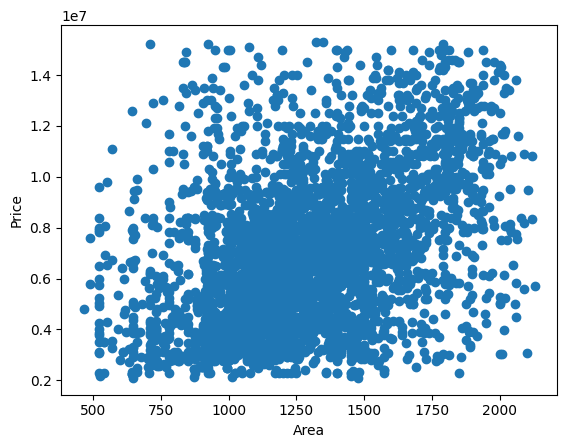

In [220]:
import matplotlib.pyplot as plt

plt.scatter(df['Area'], df['Price'])
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

In [221]:
print(df['Area'].corr(df['Price']))

0.42959375853059784
